# NDVI from *GroenMonitor*

Average the daily *GroenMonitor* NDVI rasters of a month for an area of interest with `download_avg_ndvi_month()`, or over several months with `download_avg_ndvi_stack()`. The raw WCS requests are shown in [`advanced/groenmonitor_wcs`](advanced/groenmonitor_wcs.ipynb).

**Requires:** `NDC_TOKEN` environment variable (only for the last section)

**Approximate runtime:** about 2 minutes (one request per day)

**Author:** Bruno Marcos

**Created in:** October 2, 2026

## Settings

In [1]:
# Load packages
pkgs <- c("sf", "terra", "rNDC")
suppressPackageStartupMessages(
  invisible(lapply(pkgs, FUN = library, character.only = TRUE))
)

# Study area: one of the study sites bundled with the package
site <- ndc_sites("loobos")

## 1. Monthly average NDVI

`download_avg_ndvi_month()` downloads the daily NDVI rasters of a month for the area of interest and averages them. Days without data are skipped; `download_avg_ndvi_stack()` does the same for a range of months.

In [2]:
ndvi <- download_avg_ndvi_month(site, year = 2025, month = 7)
print(ndvi)

Processing July 2025
Downloaded 3 NDVI layer(s) for the month


class       : SpatRaster
size        : 399, 549, 1  (nrow, ncol, nlyr)
resolution  : 10, 10  (x, y)
extent      : 685060, 690550, 5781020, 5785010  (xmin, xmax, ymin, ymax)
coord. ref. : WGS 84 / UTM zone 31N (EPSG:32631)
source(s)   : memory
name        : ndvi_mean_202507
min value   :                1
max value   :              233


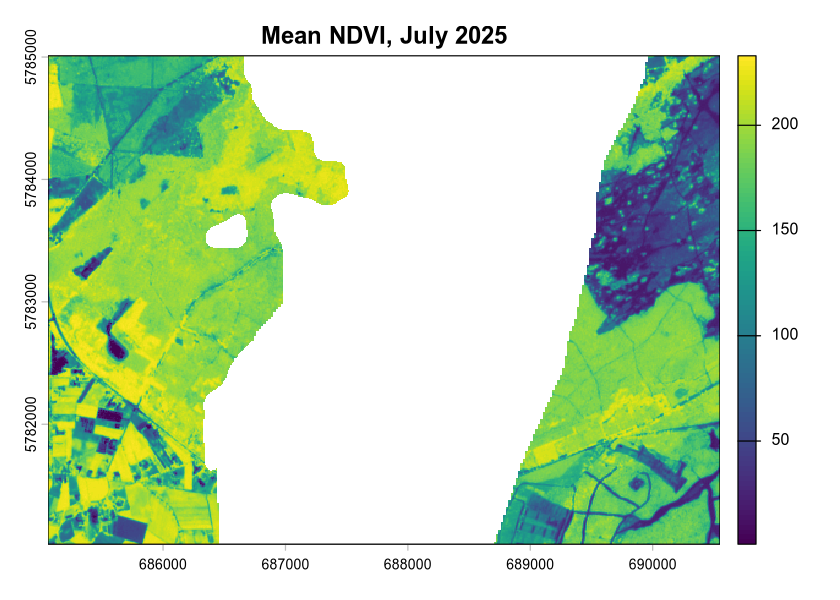

In [3]:
plot(ndvi, main = "Mean NDVI, July 2025")

## 2. Monthly averages over a period

`download_avg_ndvi_stack()` returns one layer per month, aligned on a common grid.

In [4]:
ndvi_stack <- suppressMessages(download_avg_ndvi_stack(site, start_year = 2025, start_month = 7,
                                                  end_year = 2025, end_month = 8))
print(ndvi_stack)

class       : SpatRaster
size        : 399, 549, 2  (nrow, ncol, nlyr)
resolution  : 10, 10  (x, y)
extent      : 685060, 690550, 5781020, 5785010  (xmin, xmax, ymin, ymax)
coord. ref. : WGS 84 / UTM zone 31N (EPSG:32631)
source(s)   : memory
names       : ndvi_mean_202507, ndvi_mean_202508
min values  :                1,                3
max values  :              233,              234


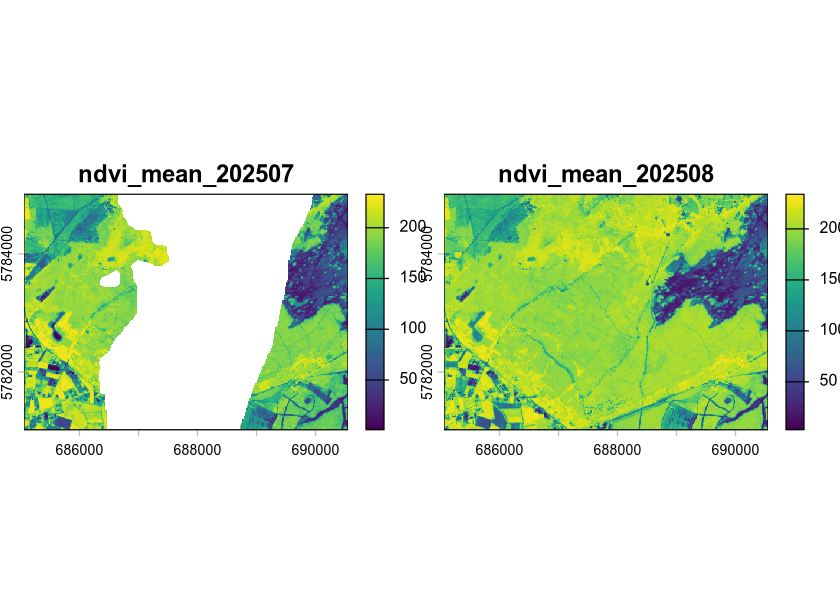

In [5]:
plot(ndvi_stack)

## 3. NDVI items in *NatureDataCube*

The same *GroenMonitor* NDVI rasters are also catalogued in the `ndvi` collection of *NatureDataCube*. `ndc_get()` lists the items that intersect the area in a time window (see [`01_getting_started`](01_getting_started.ipynb)).

In [6]:
ndvi_items <- ndc_get("ndvi", roi = site, trange = c("2025-07-01", "2025-08-31"), mode = "tibble")
ndvi_items[, c("title", "datetime")]

# A tibble: 6 × 2
  title         datetime            
  <chr>         <chr>               
1 ndvi_20250829 2025-08-29T00:00:00Z
2 ndvi_20250819 2025-08-19T00:00:00Z
3 ndvi_20250811 2025-08-11T00:00:00Z
4 ndvi_20250715 2025-07-15T00:00:00Z
5 ndvi_20250710 2025-07-10T00:00:00Z
6 ndvi_20250702 2025-07-02T00:00:00Z
